# Basic WSSS pipeline

Just dino + decoder

In [ ]:
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

In [2]:
from dataset import make_voc_datasets, wsss_collate_fn, VOC_CLASSES, colorize

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("Loading DINOv3 (ViT-Small)...")
dino_repo_dir = "./dinov3"
dino_model = torch.hub.load(
    dino_repo_dir,
    "dinov3_vits16",
    source="local",
    weights="weights/dinov3_vits16_pretrain_lvd1689m-08c60483.pth",
).to(device)
dino_model.eval()

train_ds, val_ds = make_voc_datasets(root="./data", resize_size=IMG_SIZE)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
    collate_fn=wsss_collate_fn,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=wsss_collate_fn,
)

Using device: cpu
Loading DINOv3 (ViT-Small)...


## Classifier head

Frozen DINOv3 -> GAP over patch tokens

In [ ]:
NUM_CLASSES = 20
EMBED_DIM = dino_model.embed_dim
PATCH_SIZE = dino_model.patch_size
GRID = IMG_SIZE // PATCH_SIZE
NUM_PATCHES = GRID * GRID


class CAMClassifier(nn.Module):
    """
    A single linear classifier
    """

    def __init__(self, embed_dim: int, num_classes: int):
        super().__init__()
        self.fc = nn.Linear(embed_dim, num_classes, bias=True)

    def forward(self, patch_tokens: torch.Tensor) -> torch.Tensor:
        pooled = patch_tokens.mean(dim=1)
        return self.fc(pooled)

    @torch.no_grad()
    def cam(self, patch_tokens: torch.Tensor, grid: int) -> torch.Tensor:
        """
        Raw CAM on the patch grid: [B, C, grid, grid] (no normalization).
        Similar to Zhou et al., CVPR 2016
        """
        B, P, D = patch_tokens.shape
        feats = patch_tokens.transpose(1, 2).reshape(B, D, grid, grid)
        W = self.fc.weight
        cams = F.conv2d(feats, W.unsqueeze(-1).unsqueeze(-1))
        return cams


classifier = CAMClassifier(EMBED_DIM, NUM_CLASSES).to(device)
print(classifier)

CAMClassifier(
  (fc): Linear(in_features=384, out_features=20, bias=True)
)


## Cache DINO patch tokens

DINO is frozen, so we extract patch tokens once and keep them on device

In [4]:
from tqdm.auto import tqdm


def cache_dino_tokens(dataset, loader, store_device=device, dtype=torch.float16):
    """Getting dino tokens just once and caching them."""
    n = len(dataset)
    cache = torch.zeros((n, NUM_PATCHES, EMBED_DIM), dtype=dtype, device=store_device)
    labels = torch.zeros((n, NUM_CLASSES), dtype=torch.float32, device=store_device)
    with torch.inference_mode():
        for indices, images, label_vec in tqdm(loader, desc="Caching DINO"):
            images = images.to(device, non_blocking=True)
            feats = dino_model.forward_features(images)["x_norm_patchtokens"]
            cache[indices] = feats.to(dtype)
            labels[indices] = label_vec.to(store_device)
    mem_gb = cache.element_size() * cache.nelement() / (1024 ** 3)
    print(f"Cached {n} samples ({mem_gb:.2f} GB on {store_device}).")
    return cache, labels

train_cache_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, collate_fn=wsss_collate_fn,
)
val_cache_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, collate_fn=wsss_collate_fn,
)

train_tokens, train_labels = cache_dino_tokens(train_ds, train_cache_loader)
val_tokens,   val_labels   = cache_dino_tokens(val_ds,   val_cache_loader)

/Users/anthony/Code/cs484-wsss/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Caching DINO:   0%|          | 0/46 [00:00<?, ?it/s]

Cached 1464 samples (0.21 GB on cpu).


Caching DINO:   0%|          | 0/46 [00:00<?, ?it/s]

Cached 1449 samples (0.20 GB on cpu).


## Train the classifier

NN things

In [5]:
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = AdamW(classifier.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
bce = nn.BCEWithLogitsLoss()


def cached_batches(tokens, labels, batch_size, shuffle=True):
    n = tokens.shape[0]
    order = torch.randperm(n, device=tokens.device) if shuffle else torch.arange(n, device=tokens.device)
    for i in range(0, n, batch_size):
        idx = order[i : i + batch_size]
        yield tokens[idx].float(), labels[idx]


@torch.no_grad()
def eval_classifier(tokens, labels, batch_size=256):
    classifier.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in cached_batches(tokens, labels, batch_size, shuffle=False):
        logits = classifier(x)
        loss_sum += bce(logits, y).item() * x.size(0)
        pred = (logits.sigmoid() > 0.5).float()
        correct += ((pred == y).float().mean(dim=1) == 1).sum().item()
        total += x.size(0)
    return loss_sum / total, correct / total


history = {"train_loss": [], "val_loss": [], "val_exact": []}
for epoch in range(1, EPOCHS + 1):
    classifier.train()
    epoch_loss, n_seen = 0.0, 0
    for x, y in cached_batches(train_tokens, train_labels, BATCH_SIZE, shuffle=True):
        optimizer.zero_grad()
        loss = bce(classifier(x), y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x.size(0)
        n_seen += x.size(0)
    scheduler.step()

    train_loss = epoch_loss / n_seen
    val_loss, val_exact = eval_classifier(val_tokens, val_labels)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_exact"].append(val_exact)
    print(f"epoch {epoch:02d} | train BCE {train_loss:.4f} "
          f"| val BCE {val_loss:.4f} | val exact-match {val_exact:.3f}")

epoch 01 | train BCE 0.4422 | val BCE 0.2934 | val exact-match 0.000
epoch 02 | train BCE 0.2515 | val BCE 0.2239 | val exact-match 0.017
epoch 03 | train BCE 0.2076 | val BCE 0.1948 | val exact-match 0.043
epoch 04 | train BCE 0.1831 | val BCE 0.1751 | val exact-match 0.098
epoch 05 | train BCE 0.1654 | val BCE 0.1602 | val exact-match 0.156
epoch 06 | train BCE 0.1519 | val BCE 0.1487 | val exact-match 0.218
epoch 07 | train BCE 0.1413 | val BCE 0.1399 | val exact-match 0.266
epoch 08 | train BCE 0.1329 | val BCE 0.1327 | val exact-match 0.308
epoch 09 | train BCE 0.1262 | val BCE 0.1270 | val exact-match 0.344
epoch 10 | train BCE 0.1207 | val BCE 0.1223 | val exact-match 0.371
epoch 11 | train BCE 0.1160 | val BCE 0.1184 | val exact-match 0.391
epoch 12 | train BCE 0.1121 | val BCE 0.1152 | val exact-match 0.408
epoch 13 | train BCE 0.1089 | val BCE 0.1124 | val exact-match 0.427
epoch 14 | train BCE 0.1060 | val BCE 0.1101 | val exact-match 0.441
epoch 15 | train BCE 0.1036 | val 

## CAM extraction

In [10]:
BG_THRESHOLD = 0.25

@torch.no_grad()
def compute_cams(patch_tokens: torch.Tensor, image_labels: torch.Tensor,
                 out_size: tuple[int, int]) -> torch.Tensor:
    """
    Per-image normalized CAM, with absent classes zeroed.

    Based off https://github.com/zhoubolei/CAM
    """
    classifier.eval()
    B = patch_tokens.shape[0]
    cams = classifier.cam(patch_tokens.float(), GRID)
    cams = F.relu(cams)
    cams = F.interpolate(cams, size=out_size, mode="bilinear", align_corners=False)

    flat = cams.view(B, NUM_CLASSES, -1)
    cmin = flat.min(dim=2, keepdim=True).values
    cmax = flat.max(dim=2, keepdim=True).values
    flat = (flat - cmin) / (cmax - cmin).clamp(min=1e-6)
    cams = flat.view_as(cams)

    mask = image_labels.view(B, NUM_CLASSES, 1, 1)
    return cams * mask


def cams_to_label_map(cams: torch.Tensor, bg_threshold: float = BG_THRESHOLD) -> torch.Tensor:
    """
    Argmax over classes to produce a label map in 0..C.
    """
    B, C, H, W = cams.shape
    bg = torch.full((B, 1, H, W), bg_threshold, device=cams.device, dtype=cams.dtype)
    full = torch.cat([bg, cams], dim=1)                            # [B,C+1,H,W]
    return full.argmax(dim=1)                                      # [B,H,W]

## DenseCRF refinement

Using the same CRF methology as AffinityNet (CVPR 2018) at https://github.com/jiwoon-ahn/psa

In [ ]:
import pydensecrf.densecrf as dcrf
from pydensecrf.utils import unary_from_softmax

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
CRF_ALPHA = 8  # PSA uses 4 (low) and 32 (high); 8 is a sane single-shot middle


def denorm_to_uint8(img_t: torch.Tensor) -> np.ndarray:
    """ImageNet-normalized CHW float tensor -> HWC uint8."""
    x = img_t.detach().cpu().numpy().transpose(1, 2, 0)
    x = (x * IMAGENET_STD + IMAGENET_MEAN).clip(0.0, 1.0)
    return (x * 255.0).astype(np.uint8)


def crf_inference(img, probs, t=10, scale_factor=1, labels=21):
    """
    Adopted from https://github.com/jiwoon-ahn/psa
    """
    h, w = img.shape[:2]
    n_labels = labels

    d = dcrf.DenseCRF2D(w, h, n_labels)

    rgbim = np.ascontiguousarray(img, dtype=np.uint8)
    unary = np.ascontiguousarray(unary_from_softmax(probs))

    d.setUnaryEnergy(unary)
    d.addPairwiseGaussian(sxy=3 / scale_factor, compat=3)
    d.addPairwiseBilateral(sxy=80 / scale_factor, srgb=13, rgbim=rgbim, compat=10)
    Q = d.inference(t)

    return np.array(Q).reshape((n_labels, h, w))


def _crf_with_alpha(orig_img, cam_dict, alpha):
    v = np.array(list(cam_dict.values()))
    bg_score = np.power(1 - np.max(v, axis=0, keepdims=True), alpha)
    bgcam_score = np.ascontiguousarray(np.concatenate((bg_score, v), axis=0),
                                       dtype=np.float32)
    crf_score = crf_inference(orig_img, bgcam_score, labels=bgcam_score.shape[0])

    n_crf_al = dict()
    n_crf_al[0] = crf_score[0]
    for i, key in enumerate(cam_dict.keys()):
        n_crf_al[key + 1] = crf_score[i + 1]
    return n_crf_al


def dense_crf(image_uint8: np.ndarray, cam: np.ndarray,
              alpha: float = CRF_ALPHA) -> np.ndarray:
    """
    Run PSA-style DenseCRF on a single image.
    """
    H, W = image_uint8.shape[:2]
    cam_dict = {c: cam[c] for c in range(cam.shape[0]) if cam[c].max() > 0}
    if not cam_dict:
        return np.zeros((H, W), dtype=np.int32)

    crf_dict = _crf_with_alpha(image_uint8, cam_dict, alpha)
    full = np.zeros((1 + cam.shape[0], H, W), dtype=np.float32)
    for k, v in crf_dict.items():
        full[k] = v
    return full.argmax(axis=0).astype(np.int32)


def refine_batch(images: torch.Tensor, cams: torch.Tensor,
                 alpha: float = CRF_ALPHA) -> np.ndarray:
    """
    Run DenseCRF on each image in the batch.
    """
    B, _, H, W = images.shape
    out = np.zeros((B, H, W), dtype=np.int32)
    cams_np = cams.detach().cpu().numpy()
    for b in range(B):
        out[b] = dense_crf(denorm_to_uint8(images[b]), cams_np[b], alpha=alpha)
    return out



## Visualize CAMs and CRF refinement

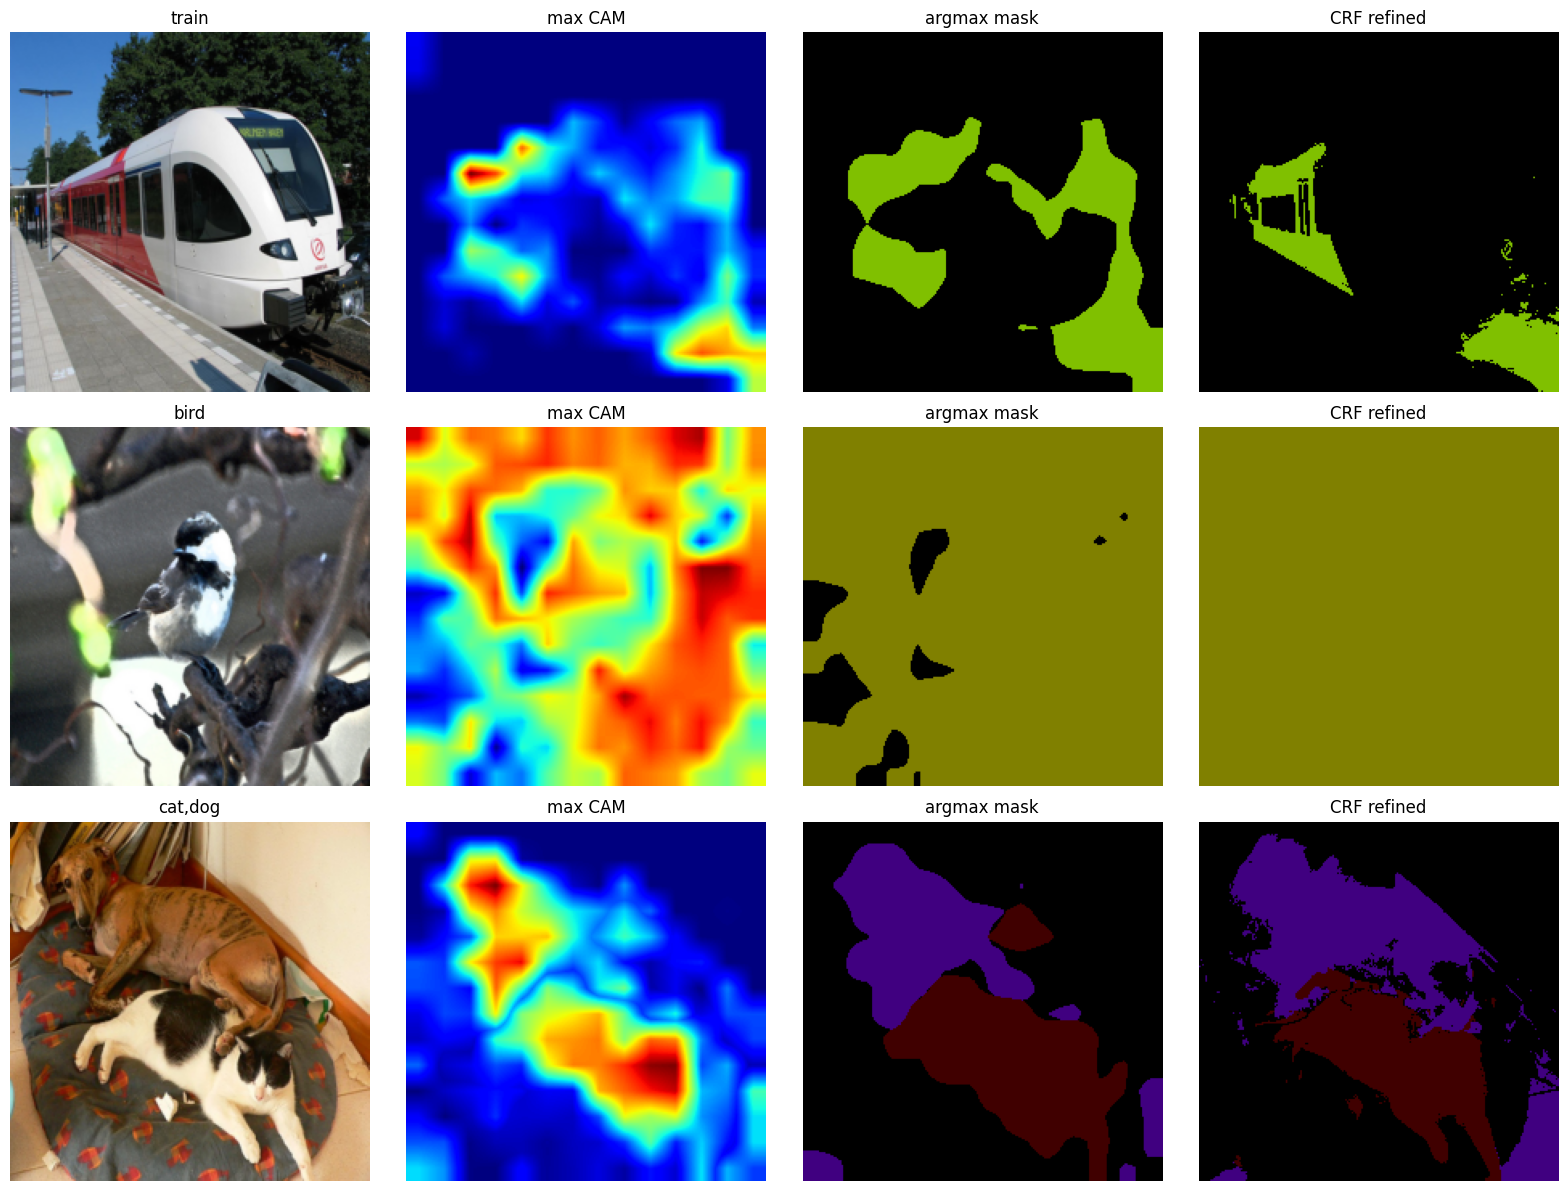

In [ ]:
import matplotlib.pyplot as plt
import random


def visualize(num_images: int = 3, seed: int = 0):
    rng = random.Random(seed)
    indices = rng.sample(range(len(val_ds)), num_images)

    fig, axes = plt.subplots(num_images, 4, figsize=(16, 4 * num_images))
    if num_images == 1:
        axes = [axes]

    for row, idx in zip(axes, indices):
        _, img_t, label_vec = val_ds[idx]
        img_batch = img_t.unsqueeze(0).to(device)
        label_batch = label_vec.unsqueeze(0).to(device)
        tokens = val_tokens[idx].unsqueeze(0).float()

        cams = compute_cams(tokens, label_batch, out_size=(IMG_SIZE, IMG_SIZE))
        raw_labels = cams_to_label_map(cams)[0].cpu().numpy()
        crf_labels = refine_batch(img_batch, cams)[0]

        present = [VOC_CLASSES[c] for c in torch.where(label_vec > 0)[0].tolist()]
        cam_vis = cams[0].max(dim=0).values.cpu().numpy()

        row[0].imshow(denorm_to_uint8(img_t)); row[0].set_title(",".join(present) or "(none)")
        row[1].imshow(cam_vis, cmap="jet", vmin=0, vmax=1); row[1].set_title("max CAM")
        row[2].imshow(colorize(raw_labels)); row[2].set_title("pre-CRF mask")
        row[3].imshow(colorize(crf_labels)); row[3].set_title("CRF refined")
        for ax in row:
            ax.axis("off")
    plt.tight_layout(); plt.show()


visualize(num_images=3)

## Validation mIoU

Score per-class IoU against ground-truth VOC masks for both for the raw CAM-argmax and the CRF-refined masks

In [11]:
def evaluate_miou(use_crf: bool = False, max_batches: int | None = None):
    n_cls = NUM_CLASSES + 1  # +1 background
    inter = np.zeros(n_cls, dtype=np.int64)
    union = np.zeros(n_cls, dtype=np.int64)

    loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=wsss_collate_fn,
    )

    for b_idx, (indices, images, labels) in enumerate(tqdm(loader, desc="mIoU")):
        if max_batches is not None and b_idx >= max_batches:
            break
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        tokens = val_tokens[indices].float()

        cams = compute_cams(tokens, labels, out_size=(IMG_SIZE, IMG_SIZE))
        if use_crf:
            preds = refine_batch(images, cams)
        else:
            preds = cams_to_label_map(cams).cpu().numpy()

        for i, ds_idx in enumerate(indices.tolist()):
            _, gt_pil = val_ds.voc[ds_idx]
            gt = np.array(gt_pil)
            H, W = gt.shape
            p = np.array(
                Image.fromarray(preds[i].astype(np.uint8)).resize((W, H), Image.NEAREST)
            )
            valid = gt != 255
            for c in range(n_cls):
                pc = (p == c) & valid
                tc = (gt == c) & valid
                inter[c] += np.logical_and(pc, tc).sum()
                union[c] += np.logical_or(pc, tc).sum()

    iou = inter / np.maximum(union, 1)
    present = union > 0
    miou = iou[present].mean()

    print(f"\n{'CRF' if use_crf else 'raw'} mIoU = {miou:.4f}")
    for c, name in enumerate(["background"] + VOC_CLASSES):
        if present[c]:
            print(f"  {name:<14s} {iou[c]:.4f}")
    return miou

print("\nWithout DenseCRF:")
evaluate_miou(use_crf=False)

print("\nWith DenseCRF:")
evaluate_miou(use_crf=True)


With DenseCRF:


/Users/anthony/Code/cs484-wsss/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


mIoU:   0%|          | 0/46 [00:00<?, ?it/s]


CRF mIoU = 0.3710
  background     0.4758
  aeroplane      0.1502
  bicycle        0.2037
  bird           0.1415
  boat           0.1353
  bottle         0.4998
  bus            0.6551
  car            0.4173
  cat            0.6245
  chair          0.1654
  cow            0.5592
  diningtable    0.3781
  dog            0.3511
  horse          0.5068
  motorbike      0.5033
  person         0.3750
  pottedplant    0.3810
  sheep          0.2934
  sofa           0.4453
  train          0.3060
  tvmonitor      0.2224


np.float64(0.37096018434254024)